# Cross-dataset SOC EDA — LG HG2 (NMC) ↔ Panasonic 18650PF (NCA)

**Purpose:** characterize the domain gap between the two SOC drive-cycle datasets
for the cross-dataset transfer story. Describe & visualize only — no modeling, no
windowing. Read-only on `data/processed/`.

## 0. Findings summary

Scope: **124 profiles / ~981k timesteps @ 1 Hz** — LG 69 profiles (449,334 steps),
Panasonic 55 profiles (531,570 steps). Takeaways for the transfer story:

- **SOC label support is asymmetric.** Panasonic discharges down to **SOC ≈ 0.035**
  but LG bottoms out at **SOC ≈ 0.136** (§3). A model trained on LG never sees the
  bottom ~10% of the SOC range that Panasonic occupies, so **LG→Panasonic must
  extrapolate** into unseen low-SOC, whereas Panasonic→LG only interpolates.
  Temperature support also differs: LG spans −20…40 °C, Panasonic −20…25 °C (§1).
- **Current is the largest distribution shift** (KS = **0.172**, the biggest of the
  four features vs SOC 0.161, voltage 0.152, temperature 0.135; §7), driven by
  **regen**: positive/charge current appears in **17.3%** of LG samples vs **8.0%**
  of Panasonic. The split is protocol-driven — Panasonic **warm (≥0 °C) = 12.4%**
  regen but **cold (<0 °C) = 0.0%** (discharge-only; §4). Cold-temperature current
  is effectively one-sided.
- **Chemistry leaves a clear V–SOC signature.** At matched **25 °C**, NMC (LG) vs
  NCA (Panasonic) median terminal voltage differs by **mean 42.5 mV (max 161 mV)**
  across SOC bins (§5) — a genuine chemistry gap, not a temperature artifact. The
  SOC↔voltage mapping a model learns is dataset-specific.
- **All four input marginals shift**, ranked by KS: current (0.172) > SOC (0.161) >
  voltage (0.152) > temperature (0.135); the (voltage, current) operating regions
  overlap in the discharge quadrant but diverge in the regen quadrant (§6).
- **Profiles differ in length** (median **6,568 s** LG vs **9,663 s** Panasonic) —
  Panasonic runs ~50% longer / deeper, consistent with its lower SOC floor (§2).
- **Net for transfer:** the LG↔Panasonic gap compounds chemistry (V–SOC offset),
  current/regen support, and SOC label range — expect **LG→Panasonic** (extrapolate
  to low SOC, never having seen 0% regen at cold) to be the harder direction.


### Setup & shared style

In [1]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})

# Resolve paths whether the kernel runs from the notebook dir (nbconvert default)
# or the repo root.
PROC = Path("../../data/processed")
if not (PROC / "cells.parquet").exists():
    PROC = Path("data/processed")
FIGDIR = Path("figures") if PROC.as_posix().startswith("../../") else Path("eda/cross_dataset/figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

# Consistent dataset identity across EVERY plot.
DATASETS = ["LG_HG2", "PANASONIC_18650PF"]
COLORS = {"LG_HG2": "#1f77b4", "PANASONIC_18650PF": "#d62728"}      # LG blue, Panasonic red
LABELS = {"LG_HG2": "LG HG2 (NMC)", "PANASONIC_18650PF": "Panasonic 18650PF (NCA)"}
FEATURES = ["voltage_V", "current_A", "temperature_C", "soc"]

def savefig(fig, name):
    fig.savefig(FIGDIR / name, bbox_inches="tight")

def dataset_legend(ax):
    ax.legend(handles=[Patch(color=COLORS[d], label=LABELS[d]) for d in DATASETS])

findings = {}  # collected for the section-0 summary
print("figures ->", FIGDIR.resolve())


figures -> D:\projects\soc-soh-prediction\eda\cross_dataset\figures


### Load data (merge chemistry from `cells`)

In [2]:
cells = pd.read_parquet(PROC / "cells.parquet")
soc = pd.read_parquet(PROC / "soc_timeseries.parquet")
# chemistry lives on the cells table -> merge it onto the timeseries once.
soc = soc.merge(cells[["cell_id", "chemistry"]], on="cell_id", how="left")

print(f"timesteps: {len(soc):,} | profiles: {soc['profile_id'].nunique()} | "
      f"datasets: {sorted(soc['dataset'].unique())}")
print(cells.to_string(index=False))
soc.head()


timesteps: 980,904 | profiles: 124 | datasets: ['LG_HG2', 'PANASONIC_18650PF']
          dataset              cell_id chemistry manufacturer form_factor  nominal_capacity_Ah  initial_capacity_Ah
           LG_HG2            LG_HG2_C1       NMC           LG       18650                  3.0              2.72639
PANASONIC_18650PF PANASONIC_18650PF_C1       NCA    Panasonic       18650                  2.9              2.79826


,dataset,cell_id,profile_id,nominal_temperature_C,drive_cycle,timestep,time_s,voltage_V,current_A,temperature_C,soc,chemistry
0,LG_HG2,LG_HG2_C1,LG_HG2__0degC__HWFET,0.0,HWFET,0,0.0,4.186320,-0.045970,-0.736110,1.000000,NMC
1,LG_HG2,LG_HG2_C1,LG_HG2__0degC__HWFET,0.0,HWFET,1,1.0,4.178403,-0.097010,-0.736110,0.999990,NMC
2,LG_HG2,LG_HG2_C1,LG_HG2__0degC__HWFET,0.0,HWFET,2,2.0,4.177390,-0.094500,-0.736110,0.999983,NMC
3,LG_HG2,LG_HG2_C1,LG_HG2__0degC__HWFET,0.0,HWFET,3,3.0,4.174437,-0.162249,-0.733047,0.999973,NMC
4,LG_HG2,LG_HG2_C1,LG_HG2__0degC__HWFET,0.0,HWFET,4,4.0,4.155082,-0.450883,-0.630950,0.999953,NMC


## 1. Coverage matrix

Profiles and total timesteps per (dataset × nominal temperature × drive cycle),
with a temperature×cycle pivot per dataset and a flag for missing combinations.


In [3]:
cov = (soc.groupby(["dataset", "nominal_temperature_C", "drive_cycle"], observed=True)
          .agg(profiles=("profile_id", "nunique"), timesteps=("soc", "size"))
          .reset_index()
          .sort_values(["dataset", "nominal_temperature_C", "drive_cycle"]))
print("Per (dataset × temp × cycle):")
print(cov.to_string(index=False))

for d in DATASETS:
    piv = (cov[cov.dataset == d]
           .pivot_table(index="nominal_temperature_C", columns="drive_cycle",
                        values="profiles", fill_value=0).astype(int))
    print(f"\n{LABELS[d]} — profile count (temperature × drive cycle):")
    print(piv.to_string())
    missing = [(float(t), c) for t in piv.index for c in piv.columns if piv.loc[t, c] == 0]
    print("missing temp×cycle:", missing if missing else "none")

# per-dataset totals for the summary
findings["n_profiles"] = {d: int(soc[soc.dataset == d]["profile_id"].nunique()) for d in DATASETS}
findings["n_timesteps"] = {d: int((soc.dataset == d).sum()) for d in DATASETS}
findings["temps"] = {d: sorted(map(float, soc[soc.dataset == d]["nominal_temperature_C"].unique())) for d in DATASETS}


Per (dataset × temp × cycle):
          dataset  nominal_temperature_C drive_cycle  profiles  timesteps
           LG_HG2                  -20.0       HWFET         1       3335
           LG_HG2                  -20.0        LA92         1       5254
           LG_HG2                  -20.0       MIXED         8      35675
           LG_HG2                  -20.0        UDDS         1       8191
           LG_HG2                  -20.0        US06         1       2761
           LG_HG2                  -10.0       HWFET         1       4491
           LG_HG2                  -10.0        LA92         1       7217
           LG_HG2                  -10.0       MIXED         8      48811
           LG_HG2                  -10.0        UDDS         1      12360
           LG_HG2                  -10.0        US06         1       3192
           LG_HG2                    0.0       HWFET         1       4968
           LG_HG2                    0.0        LA92         1       8167
        

## 2. Sequence lengths

Profile length (timesteps = seconds at 1 Hz) distribution per dataset.


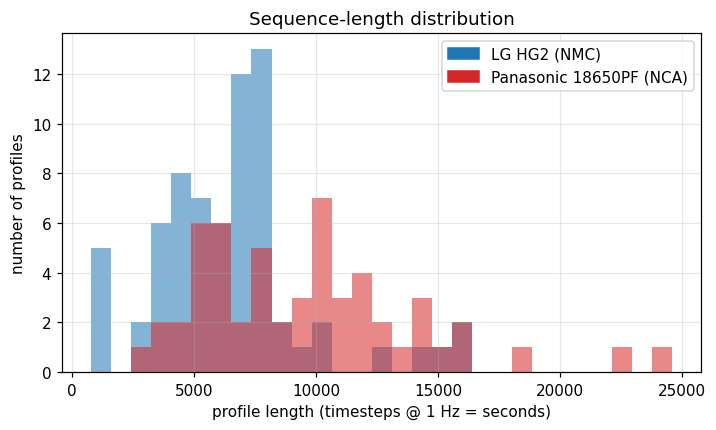

LG HG2 (NMC): median=6568  min=785  max=15966  (n_profiles=69)
Panasonic 18650PF (NCA): median=9663  min=2662  max=24610  (n_profiles=55)


In [4]:
lengths = soc.groupby(["dataset", "profile_id"], observed=True).size().reset_index(name="n")
fig, ax = plt.subplots(figsize=(7.5, 4))
bins = np.linspace(lengths["n"].min(), lengths["n"].max(), 30)
for d in DATASETS:
    ax.hist(lengths[lengths.dataset == d]["n"], bins=bins, alpha=0.55, color=COLORS[d])
ax.set_xlabel("profile length (timesteps @ 1 Hz = seconds)")
ax.set_ylabel("number of profiles")
ax.set_title("Sequence-length distribution")
dataset_legend(ax)
savefig(fig, "02_sequence_lengths.png"); plt.show()

findings["len_median"] = {}
for d in DATASETS:
    n = lengths[lengths.dataset == d]["n"]
    findings["len_median"][d] = int(n.median())
    print(f"{LABELS[d]}: median={int(n.median())}  min={int(n.min())}  max={int(n.max())}  "
          f"(n_profiles={len(n)})")


## 3. SOC coverage — the label asymmetry

Overlaid SOC histograms (density). The minimum SOC each dataset reaches is the
key label-support difference for transfer.


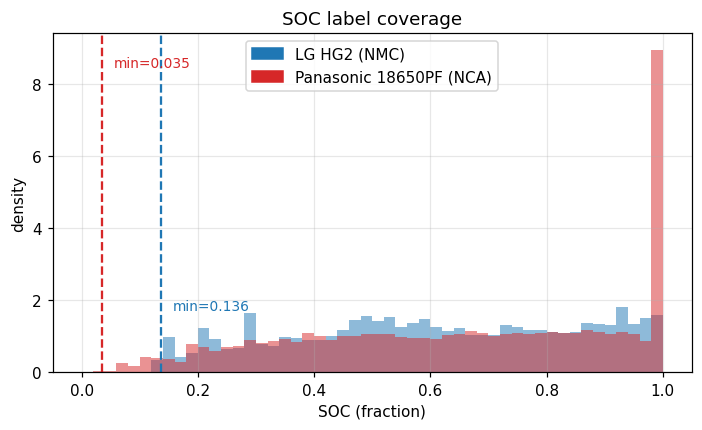

LG HG2 (NMC): SOC min=0.136  max=1.000
Panasonic 18650PF (NCA): SOC min=0.035  max=1.000


In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4))
for d in DATASETS:
    s = soc[soc.dataset == d]["soc"]
    ax.hist(s, bins=50, range=(0, 1), density=True, alpha=0.5, color=COLORS[d])
    smin = float(s.min())
    ax.axvline(smin, color=COLORS[d], ls="--", lw=1.5)
    ax.annotate(f"min={smin:.3f}", xy=(smin, ax.get_ylim()[1]*0.9),
                xytext=(smin + 0.02, ax.get_ylim()[1]*0.9), color=COLORS[d], fontsize=9)
ax.set_xlabel("SOC (fraction)"); ax.set_ylabel("density")
ax.set_title("SOC label coverage")
dataset_legend(ax)
savefig(fig, "03_soc_coverage.png"); plt.show()

findings["soc_min"] = {d: float(soc[soc.dataset == d]["soc"].min()) for d in DATASETS}
for d in DATASETS:
    print(f"{LABELS[d]}: SOC min={findings['soc_min'][d]:.3f}  max={soc[soc.dataset==d]['soc'].max():.3f}")


## 4. Input marginals — covariate shift

Overlaid densities of `voltage_V`, `current_A`, `temperature_C`. The current
panel highlights the positive (regen/charge) tail; Panasonic current is then
split into warm (≥0 °C) vs cold (<0 °C) — the cold protocol has no regen.


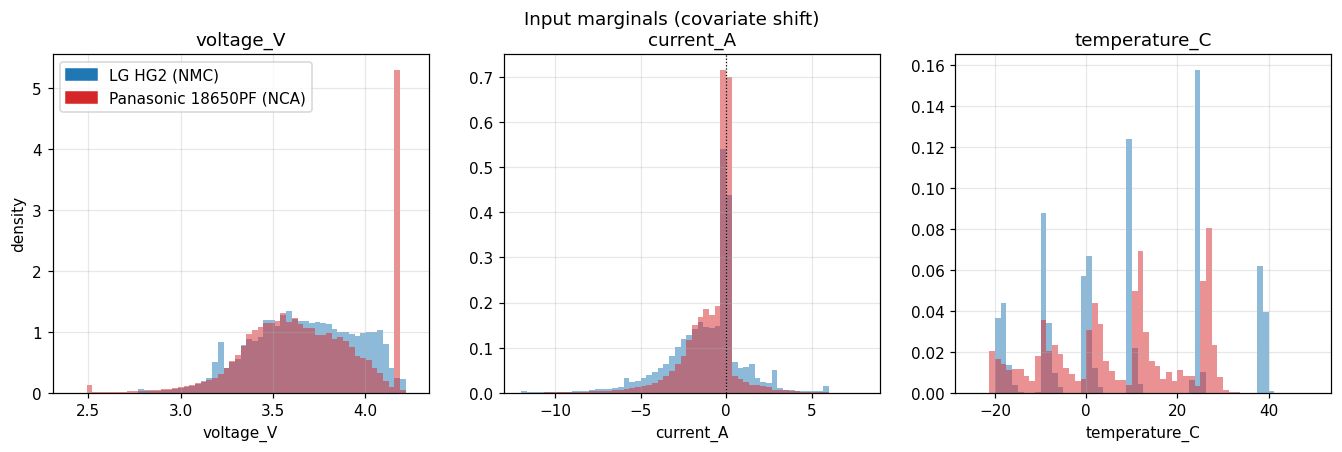

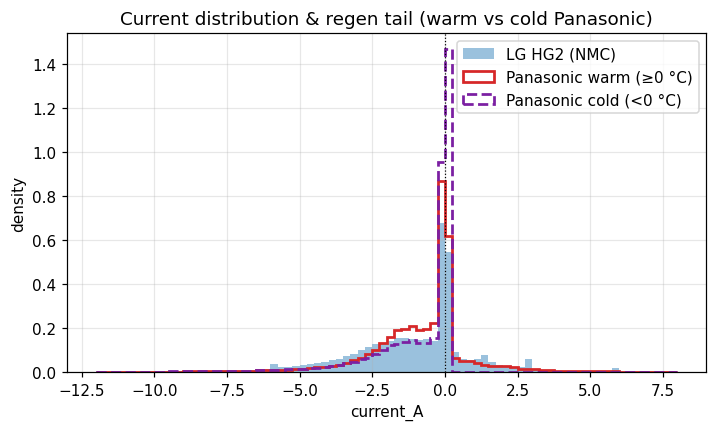

fraction of samples with current > 0.1 A (regen/charge):
  LG HG2 (NMC): 17.26%
  Panasonic 18650PF (NCA): 7.99%
  Panasonic warm(≥0°C): 12.43%  | cold(<0°C): 0.000%


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ranges = {"voltage_V": (2.4, 4.25), "current_A": (-12, 8), "temperature_C": (-25, 50)}
for ax, col in zip(axes, ["voltage_V", "current_A", "temperature_C"]):
    for d in DATASETS:
        ax.hist(soc[soc.dataset == d][col], bins=60, range=ranges[col],
                density=True, alpha=0.5, color=COLORS[d])
    ax.set_xlabel(col); ax.set_title(col)
axes[0].set_ylabel("density")
axes[1].axvline(0, color="k", lw=0.8, ls=":")
dataset_legend(axes[0])
fig.suptitle("Input marginals (covariate shift)")
savefig(fig, "04a_input_marginals.png"); plt.show()

# Regen / positive-current tail (current > +0.1 A counts as charge/regen).
REGEN = 0.1
findings["regen_frac"] = {d: float((soc[soc.dataset == d]["current_A"] > REGEN).mean()) for d in DATASETS}
pan = soc[soc.dataset == "PANASONIC_18650PF"]
pan_warm = pan[pan.nominal_temperature_C >= 0]["current_A"]
pan_cold = pan[pan.nominal_temperature_C < 0]["current_A"]
findings["pan_regen_warm"] = float((pan_warm > REGEN).mean())
findings["pan_regen_cold"] = float((pan_cold > REGEN).mean())

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(soc[soc.dataset == "LG_HG2"]["current_A"], bins=80, range=(-12, 8),
        density=True, alpha=0.45, color=COLORS["LG_HG2"], label=LABELS["LG_HG2"])
ax.hist(pan_warm, bins=80, range=(-12, 8), density=True, histtype="step", lw=1.8,
        color=COLORS["PANASONIC_18650PF"], label="Panasonic warm (≥0 °C)")
ax.hist(pan_cold, bins=80, range=(-12, 8), density=True, histtype="step", lw=1.8,
        color="#7b1fa2", ls="--", label="Panasonic cold (<0 °C)")
ax.axvline(0, color="k", lw=0.8, ls=":")
ax.set_xlabel("current_A"); ax.set_ylabel("density")
ax.set_title("Current distribution & regen tail (warm vs cold Panasonic)")
ax.legend()
savefig(fig, "04b_current_regen_tail.png"); plt.show()

print(f"fraction of samples with current > {REGEN} A (regen/charge):")
for d in DATASETS:
    print(f"  {LABELS[d]}: {findings['regen_frac'][d]*100:.2f}%")
print(f"  Panasonic warm(≥0°C): {findings['pan_regen_warm']*100:.2f}%  | "
      f"cold(<0°C): {findings['pan_regen_cold']*100:.3f}%")


## 5. Voltage–SOC relationship — the chemistry plot

Median terminal voltage vs SOC (50 bins) with inter-quartile shading, overlaid.
(a) all data, (b) 25 °C only (present in both datasets — isolates NMC vs NCA from
temperature), and (c) 25 °C + low current |I| < 0.5 A as a quasi-OCV proxy.


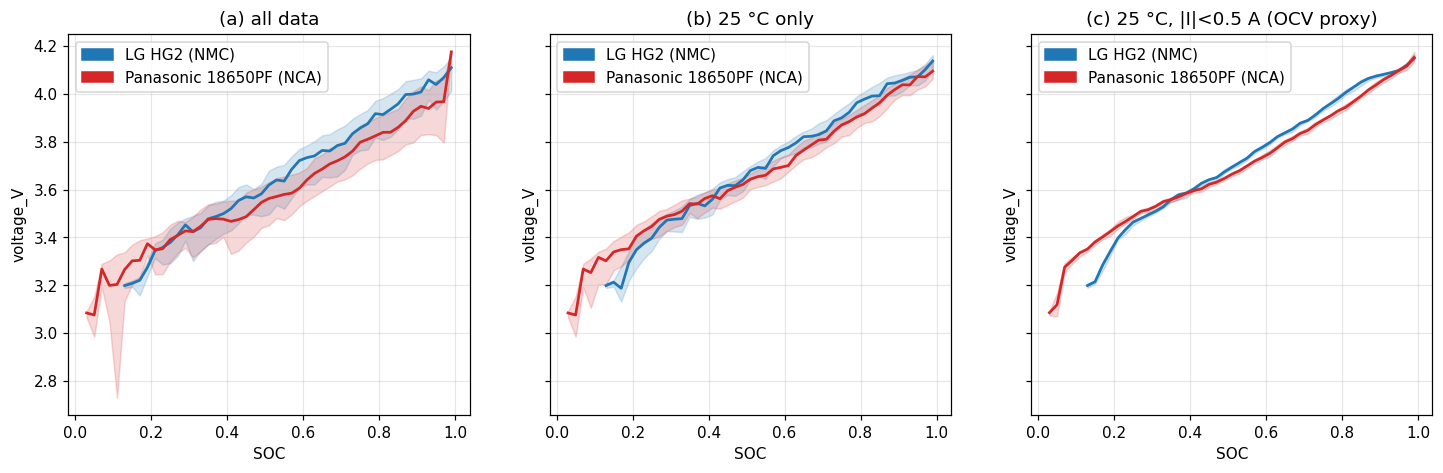

25 °C V–SOC divergence: mean |ΔV| = 42.5 mV, max |ΔV| = 161.2 mV over 44 shared SOC bins
low-current (|I|<0.5 A) 25 °C sample counts: {'LG_HG2': 32602, 'PANASONIC_18650PF': 39954}


In [7]:
SOC_BINS = np.linspace(0, 1, 51)
SOC_MID = 0.5 * (SOC_BINS[1:] + SOC_BINS[:-1])

def plot_vsoc(ax, df, title):
    curves = {}
    for d in DATASETS:
        sub = df[df.dataset == d]
        if sub.empty:
            continue
        g = sub.groupby(pd.cut(sub["soc"], SOC_BINS, include_lowest=True), observed=False)["voltage_V"]
        med, q1, q3 = g.median().values, g.quantile(0.25).values, g.quantile(0.75).values
        ax.plot(SOC_MID, med, color=COLORS[d], lw=1.8)
        ax.fill_between(SOC_MID, q1, q3, color=COLORS[d], alpha=0.18)
        curves[d] = med
    ax.set_xlabel("SOC"); ax.set_ylabel("voltage_V"); ax.set_title(title)
    dataset_legend(ax)
    return curves

soc25 = soc[soc.nominal_temperature_C == 25.0]
soc25_lowI = soc25[soc25["current_A"].abs() < 0.5]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
plot_vsoc(axes[0], soc, "(a) all data")
curves25 = plot_vsoc(axes[1], soc25, "(b) 25 °C only")
plot_vsoc(axes[2], soc25_lowI, "(c) 25 °C, |I|<0.5 A (OCV proxy)")
savefig(fig, "05_voltage_vs_soc.png"); plt.show()

# Quantify the 25 °C divergence: mean |ΔV| between datasets over shared SOC bins.
both = ~np.isnan(curves25["LG_HG2"]) & ~np.isnan(curves25["PANASONIC_18650PF"])
gap = np.abs(curves25["LG_HG2"][both] - curves25["PANASONIC_18650PF"][both])
findings["vsoc25_meangap_mV"] = float(np.mean(gap) * 1000)
findings["vsoc25_maxgap_mV"] = float(np.max(gap) * 1000)
findings["lowI_counts"] = {d: int((soc25_lowI.dataset == d).sum()) for d in DATASETS}
print(f"25 °C V–SOC divergence: mean |ΔV| = {findings['vsoc25_meangap_mV']:.1f} mV, "
      f"max |ΔV| = {findings['vsoc25_maxgap_mV']:.1f} mV over {int(both.sum())} shared SOC bins")
print(f"low-current (|I|<0.5 A) 25 °C sample counts: {findings['lowI_counts']}")
if min(findings["lowI_counts"].values()) < 5000:
    print("CAVEAT: low-current 25 °C support is sparse — treat panel (c) qualitatively.")


## 6. Input-space overlap

2-D hexbin of (voltage, current) per dataset on shared axes — where the two
operating regions overlap vs diverge.


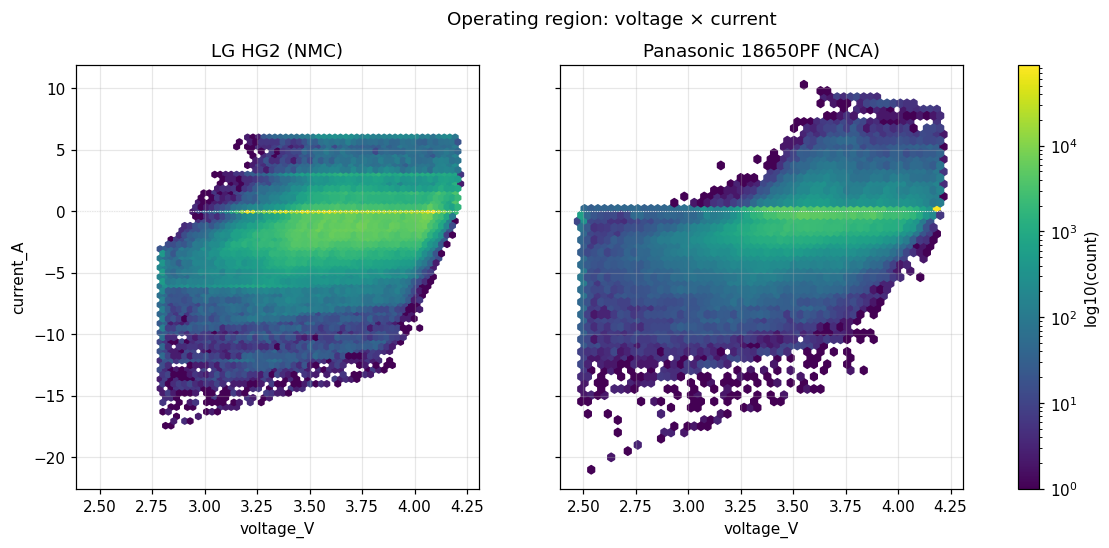

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
hb = None
for ax, d in zip(axes, DATASETS):
    sub = soc[soc.dataset == d]
    hb = ax.hexbin(sub["voltage_V"], sub["current_A"], gridsize=55, bins="log",
                   cmap="viridis", mincnt=1)
    ax.set_title(LABELS[d]); ax.set_xlabel("voltage_V")
    ax.axhline(0, color="w", lw=0.6, ls=":")
axes[0].set_ylabel("current_A")
fig.colorbar(hb, ax=axes, label="log10(count)")
fig.suptitle("Operating region: voltage × current")
savefig(fig, "06_input_overlap_hexbin.png"); plt.show()


## 7. Quantitative domain shift

Per-dataset summary statistics for V/I/T/SOC and a two-sample Kolmogorov–Smirnov
statistic (LG vs Panasonic) per feature. KS is computed on a fixed 200 k-sample
subsample per dataset for speed (statistic is the max CDF gap; p-values are ~0 at
this N and not informative).


In [9]:
rows = []
for d in DATASETS:
    sub = soc[soc.dataset == d]
    for col in FEATURES:
        x = sub[col]
        rows.append([LABELS[d], col, x.mean(), x.std(), x.min(),
                     x.quantile(0.05), x.median(), x.quantile(0.95), x.max()])
stat_tbl = pd.DataFrame(rows, columns=["dataset", "feature", "mean", "std", "min",
                                       "p5", "p50", "p95", "max"]).round(3)
print(stat_tbl.to_string(index=False))

rng = np.random.default_rng(0)
def subsample(x, n=200_000):
    x = np.asarray(x)
    return x if len(x) <= n else rng.choice(x, n, replace=False)

ks_rows = []
findings["ks"] = {}
for col in FEATURES:
    a = subsample(soc[soc.dataset == "LG_HG2"][col].values)
    b = subsample(soc[soc.dataset == "PANASONIC_18650PF"][col].values)
    ks = stats.ks_2samp(a, b)
    ks_rows.append([col, ks.statistic])
    findings["ks"][col] = float(ks.statistic)
ks_tbl = pd.DataFrame(ks_rows, columns=["feature", "ks_statistic"]).round(4)
print("\nKS two-sample statistic (LG vs Panasonic):")
print(ks_tbl.to_string(index=False))

biggest = max(findings["ks"], key=findings["ks"].get)
findings["largest_ks"] = [biggest, findings["ks"][biggest]]
print(f"\nlargest distribution shift: {biggest} (KS={findings['ks'][biggest]:.3f})")


                dataset       feature   mean    std     min      p5    p50    p95    max
           LG HG2 (NMC)     voltage_V  3.666  0.286   2.787   3.197  3.670  4.097  4.220
           LG HG2 (NMC)     current_A -1.137  2.324 -17.426  -5.360 -0.530  2.100  6.005
           LG HG2 (NMC) temperature_C  8.367 17.978 -20.190 -18.718  9.254 38.804 40.802
           LG HG2 (NMC)           soc  0.605  0.243   0.136   0.209  0.602  0.968  1.000
Panasonic 18650PF (NCA)     voltage_V  3.691  0.333   2.474   3.174  3.673  4.176  4.216
Panasonic 18650PF (NCA)     current_A -0.840  1.724 -21.004  -3.878 -0.117  0.821 10.280
Panasonic 18650PF (NCA) temperature_C  6.856 14.737 -20.343 -18.400  9.818 27.301 32.770
Panasonic 18650PF (NCA)           soc  0.657  0.271   0.035   0.200  0.681  1.000  1.000



KS two-sample statistic (LG vs Panasonic):
      feature  ks_statistic
    voltage_V        0.1517
    current_A        0.1721
temperature_C        0.1352
          soc        0.1612

largest distribution shift: current_A (KS=0.172)


## 8. Example profiles

Two representative profiles per dataset (US06 and UDDS at 25 °C) — stacked
V/I/T/SOC vs time, to confirm coulomb-counted SOC is physical (starts ~1.0,
decreases monotonically in trend, drive-cycle structure visible).


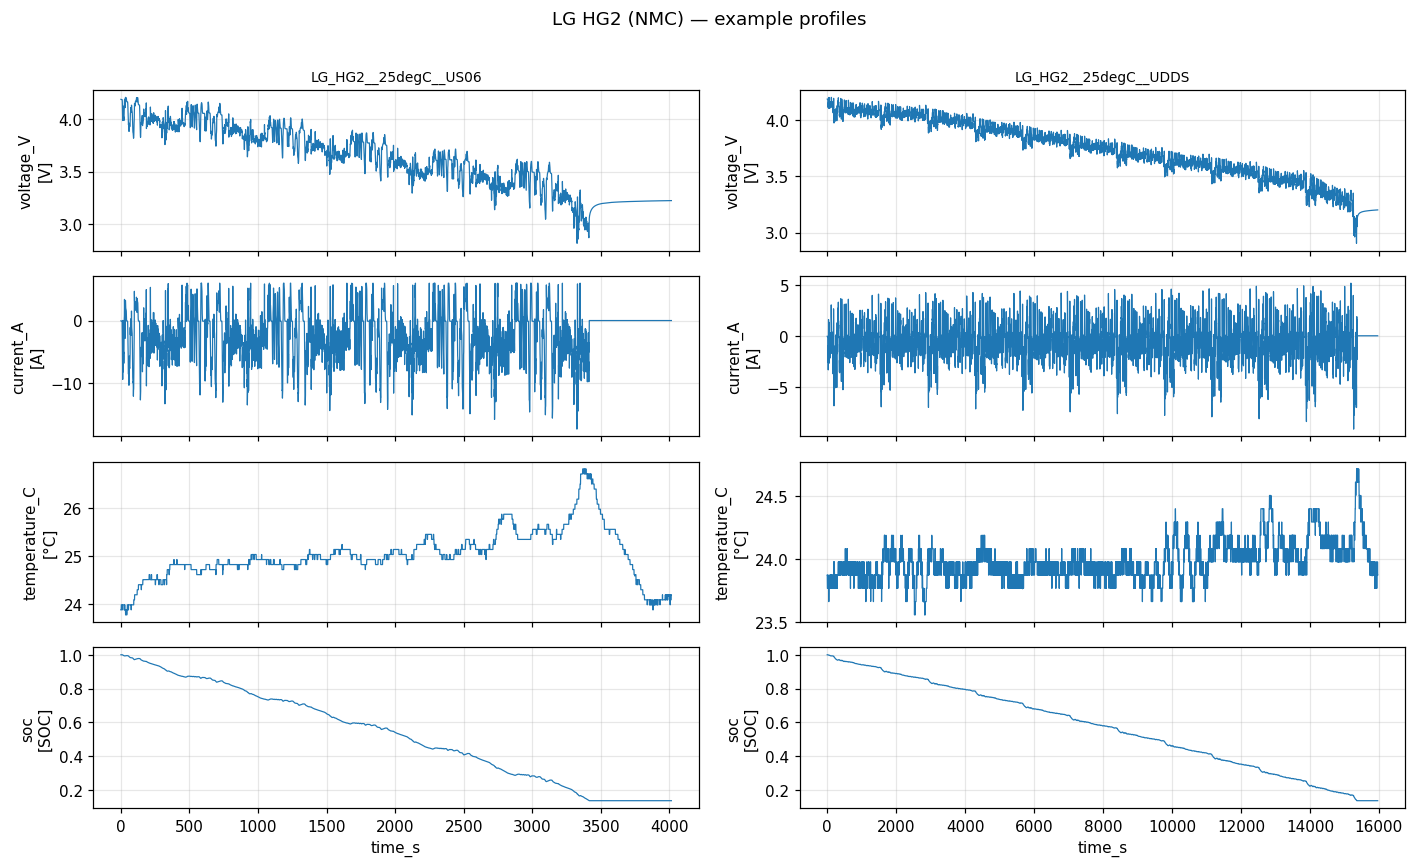

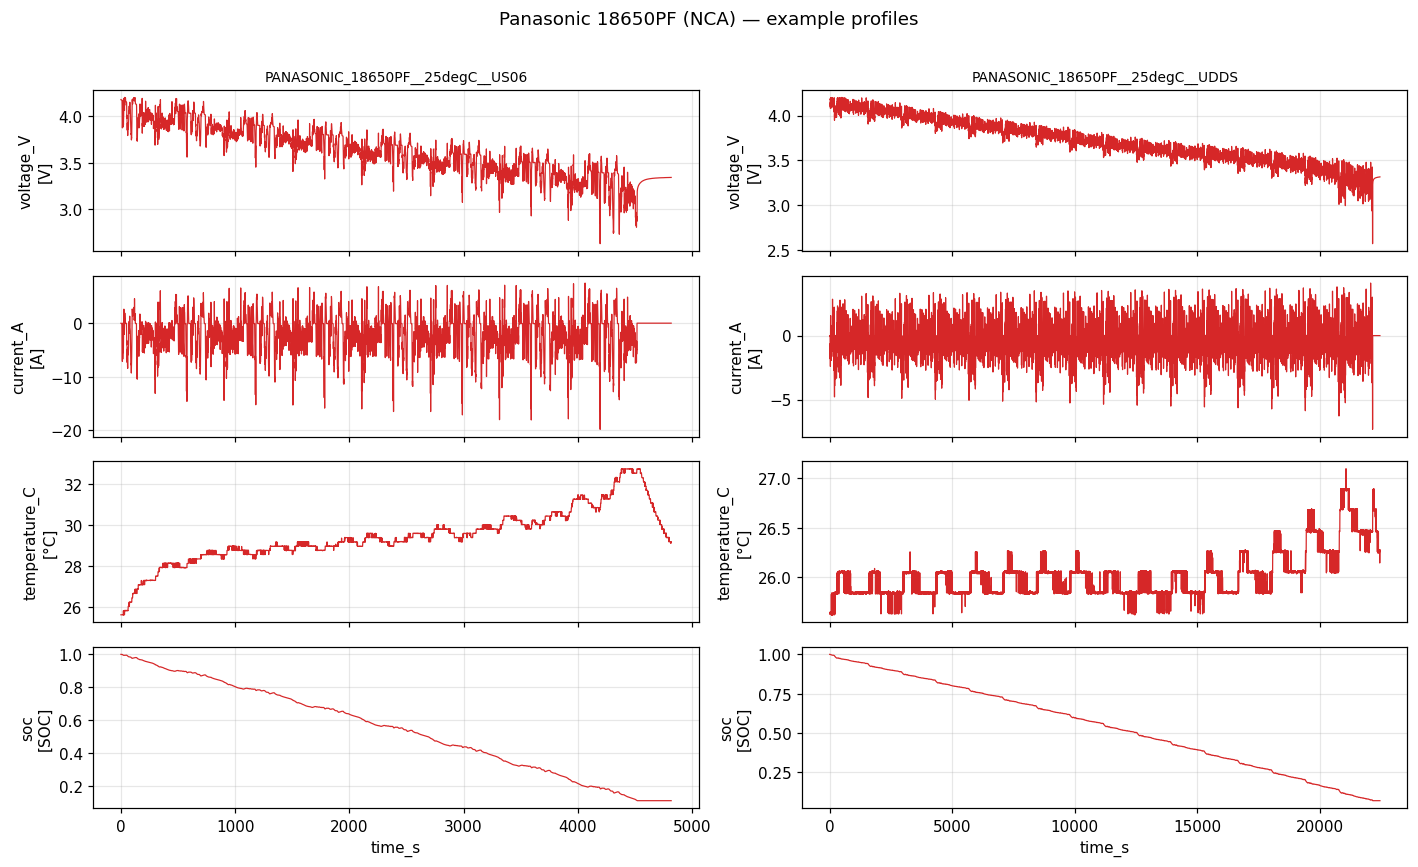

In [10]:
def pick(dataset, cycle, temp=25.0):
    cand = soc[(soc.dataset == dataset) & (soc.drive_cycle == cycle)
               & (soc.nominal_temperature_C == temp)]["profile_id"].unique()
    if len(cand):
        return sorted(cand)[0]
    any_c = soc[(soc.dataset == dataset) & (soc.drive_cycle == cycle)]["profile_id"].unique()
    return sorted(any_c)[0]

CHANNELS = [("voltage_V", "V"), ("current_A", "A"), ("temperature_C", "°C"), ("soc", "SOC")]
for d in DATASETS:
    pids = [pick(d, "US06"), pick(d, "UDDS")]
    fig, axes = plt.subplots(4, 2, figsize=(13, 8), sharex="col")
    for j, pid in enumerate(pids):
        g = soc[soc.profile_id == pid].sort_values("timestep")
        for i, (col, unit) in enumerate(CHANNELS):
            ax = axes[i, j]
            ax.plot(g["time_s"], g[col], color=COLORS[d], lw=0.8)
            ax.set_ylabel(f"{col}\n[{unit}]")
            if i == 0:
                ax.set_title(pid, fontsize=9)
        axes[3, j].set_xlabel("time_s")
    fig.suptitle(f"{LABELS[d]} — example profiles")
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    savefig(fig, f"08_examples_{'LG' if d=='LG_HG2' else 'PAN'}.png"); plt.show()


In [11]:
# Machine-readable findings (used to fill the section-0 summary).
print("FINDINGS_JSON " + json.dumps(findings, sort_keys=True))


FINDINGS_JSON {"ks": {"current_A": 0.17210999999999999, "soc": 0.16115500000000005, "temperature_C": 0.13519499999999995, "voltage_V": 0.15166000000000002}, "largest_ks": ["current_A", 0.17210999999999999], "len_median": {"LG_HG2": 6568, "PANASONIC_18650PF": 9663}, "lowI_counts": {"LG_HG2": 32602, "PANASONIC_18650PF": 39954}, "n_profiles": {"LG_HG2": 69, "PANASONIC_18650PF": 55}, "n_timesteps": {"LG_HG2": 449334, "PANASONIC_18650PF": 531570}, "pan_regen_cold": 0.0, "pan_regen_warm": 0.1243149131662497, "regen_frac": {"LG_HG2": 0.1725954412530545, "PANASONIC_18650PF": 0.07992174125703105}, "soc_min": {"LG_HG2": 0.13613666666666668, "PANASONIC_18650PF": 0.03511379310344831}, "temps": {"LG_HG2": [-20.0, -10.0, 0.0, 10.0, 25.0, 40.0], "PANASONIC_18650PF": [-20.0, -10.0, 0.0, 10.0, 25.0]}, "vsoc25_maxgap_mV": 161.2261547802154, "vsoc25_meangap_mV": 42.526040548480836}
